# Gini


In [1]:
%load_ext autoreload
%autoreload 2
from urban_mobility import fetch_data as fd
from urban_mobility.utils import cached_df
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from urban_mobility import plotting as pl

In [2]:
city_info = fd.get_city_info()

In [3]:
YEARS = [i for i in range(2019, 2025)]

## Data Cleaning


Aggregate the accidents and join them with the city info (`fd.get_city_aggregate`): it one-hot encodes the injury severity, groups by the columns given, joins on `"regional key"` and adds the total injuries. The result is cached under `output/artifacts`.


In [4]:
agg_methods = {
    "inj_light": "sum",
    "inj_serious": "sum",
    "inj_fatal": "sum",
    "IstFuss": "sum",
    "IstRad": "sum",
    "IstKrad": "sum",
    "IstGkfz": "sum",
    "ULAND": "first",
}

df_merged = fd.get_city_aggregate(YEARS, ["Community_key", "UJAHR"], agg_methods)

In [5]:
# Sanity check
df_merged[df_merged["UJAHR"] == 2024].head()

,regional key,UJAHR,inj_light,inj_serious,inj_fatal,IstFuss,IstRad,IstKrad,IstGkfz,ULAND,city,sq km,population,inj_total
5,01001000,2024,325,22,2,34,151,29,14,01,Flensburg,56.73,96326,349
11,01002000,2024,930,93,4,102,514,68,28,01,Kiel,118.65,252668,1027
17,01003000,2024,1008,109,1,104,611,93,28,01,Lübeck,214.19,216889,1118
23,01004000,2024,329,33,0,32,136,28,16,01,Neumünster,71.66,79809,362
29,01051011,2024,51,9,0,5,25,10,2,01,Brunsbüttel,65.21,12692,60


## Gini

We calculate the gini-index. Normally, the gini-index is used as a measure for wealth disparity. Here, we seek to use it as a metric to inform about the relative share of fatalities between cities. In this context, a gini-index of 0 would mean that fatalities are equally distributed between cities while a gini-index of 1 would mean that the fatalities are are concentrated in one city. On our dataset it is possible to obtain a negative gini-index. This can be interpreted as lower-population cities contributing more to the category than their higher-population counterparts. If all one cares about is to quantify the disparity disregarding the direction, one can take the absolute value of the gini-index so it is in the range `[0, 1]`.


In [6]:
pop_label = "population"

In [7]:
# @lucasboettcher - GitLab - https://gitlab.com/ComputationalScience/overdose-da/-/blob/main/county_plot/county_plots.ipynb
def calc_gini(
    df: pd.DataFrame, pop_label: str = pop_label, val_label: str = "IstRad"
) -> float:
    """Calculate the Gini index for a given dataframe.

    Args:
        df (pd.DataFrame): DataFrame containing population and value columns.
        pop_label (str): Column name for population data.
        val_label (str): Column name for value data.

    Returns:
        float: Gini index.
    """
    df_sorted = df.sort_values(pop_label, ascending=True)
    pop = df_sorted[pop_label].sum()
    val = df_sorted[val_label].sum()

    gini = 1 - 2 * np.trapezoid(
        x=[df_sorted[:i][pop_label].sum() / pop for i in range(1 + len(df_sorted))],
        y=[df_sorted[:i][val_label].sum() / val for i in range(1 + len(df_sorted))],
    )

    # NOTE: The gini-index is typically [0,1] for wealth. However, it is possible to
    # have negative values here, indicating that the lower population segments
    # contribute more than their "fair share" compared to their higher-population
    # counterparts.
    return gini

In [8]:
def plot_lorenz_curve(
    df: pd.DataFrame,
    year: int,
    pop_label: str = pop_label,
    val_label: str = "IstRad",
    val_title: None | str = None,
    ax=None,
):
    """Lorenz curve of ``val_label`` against population, ordered by population."""
    df_sorted = df.sort_values(by=pop_label, ascending=True)
    pop = df_sorted[pop_label].cumsum() / df_sorted[pop_label].sum()
    val = df_sorted[val_label].cumsum() / df_sorted[val_label].sum()
    val_title = val_label if val_title is None else val_title

    return pl.lorenz(
        np.insert(pop.values, 0, 0),
        np.insert(val.values, 0, 0),
        calc_gini(df, pop_label=pop_label, val_label=val_label),
        f"{val_title} ({year})",
        val_title,
        ax=ax,
    )

Plot the Lorenz Curve for certain categories and types.


In [9]:
# LUT for human-readable labels
vals = {
    # injury category
    "inj_total": "Total Injuries",
    "inj_light": "Light Injuries",
    "inj_serious": "Serious Injuries",
    "inj_fatal": "Fatal Injuries",
    # participant type
    "IstFuss": "Pedestrian Accidents",
    "IstRad": "Cyclist Accidents",
    "IstKrad": "Motorcycle Accidents",
    "IstGkfz": "Delivery Vehicle Accidents",
}

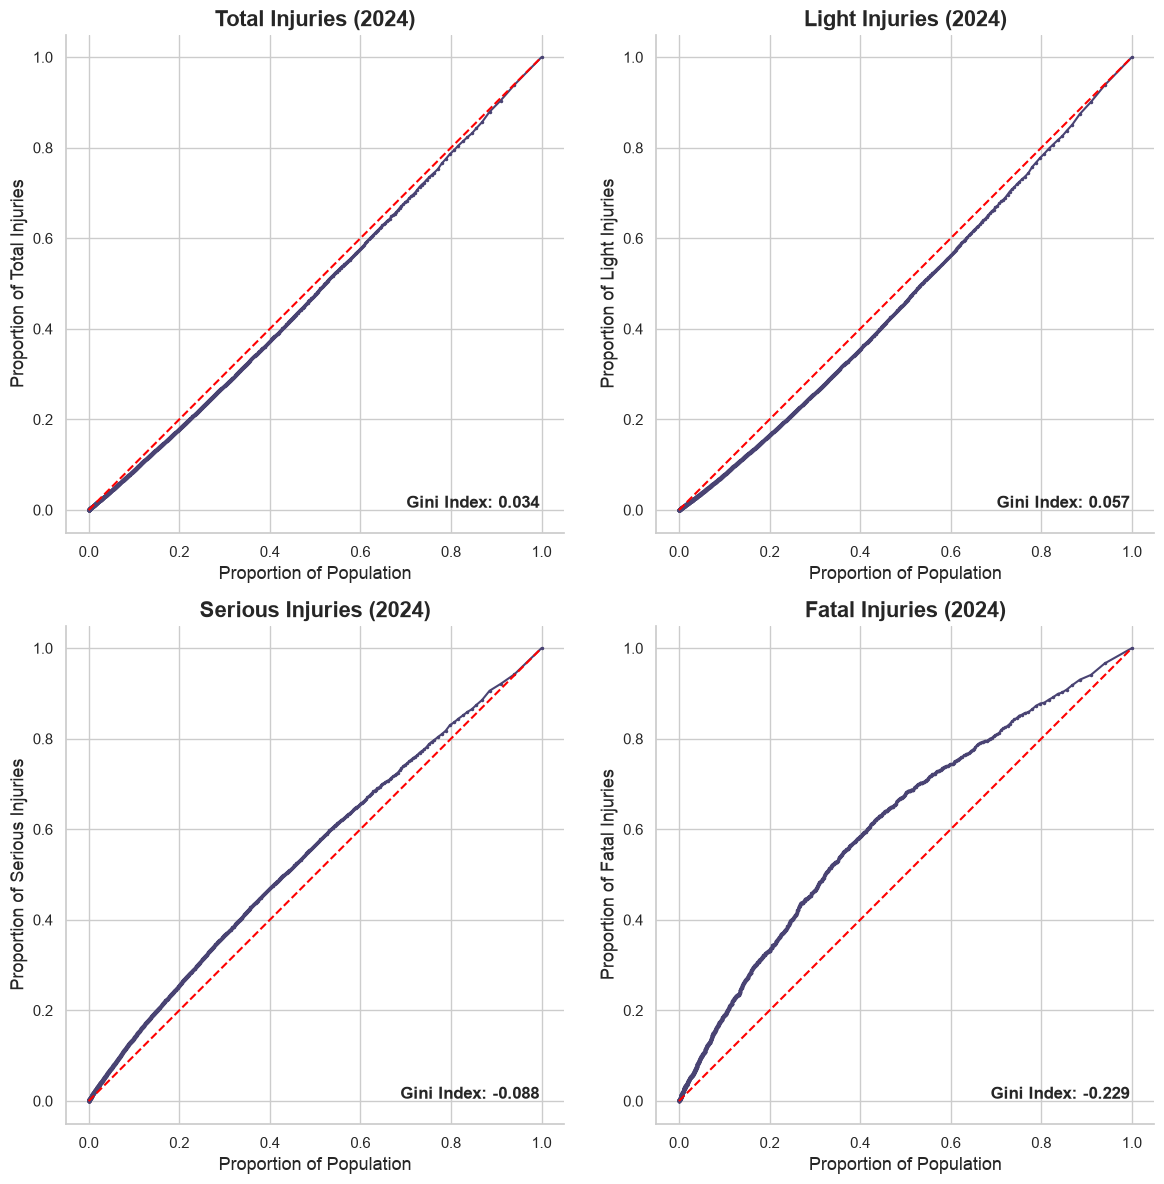

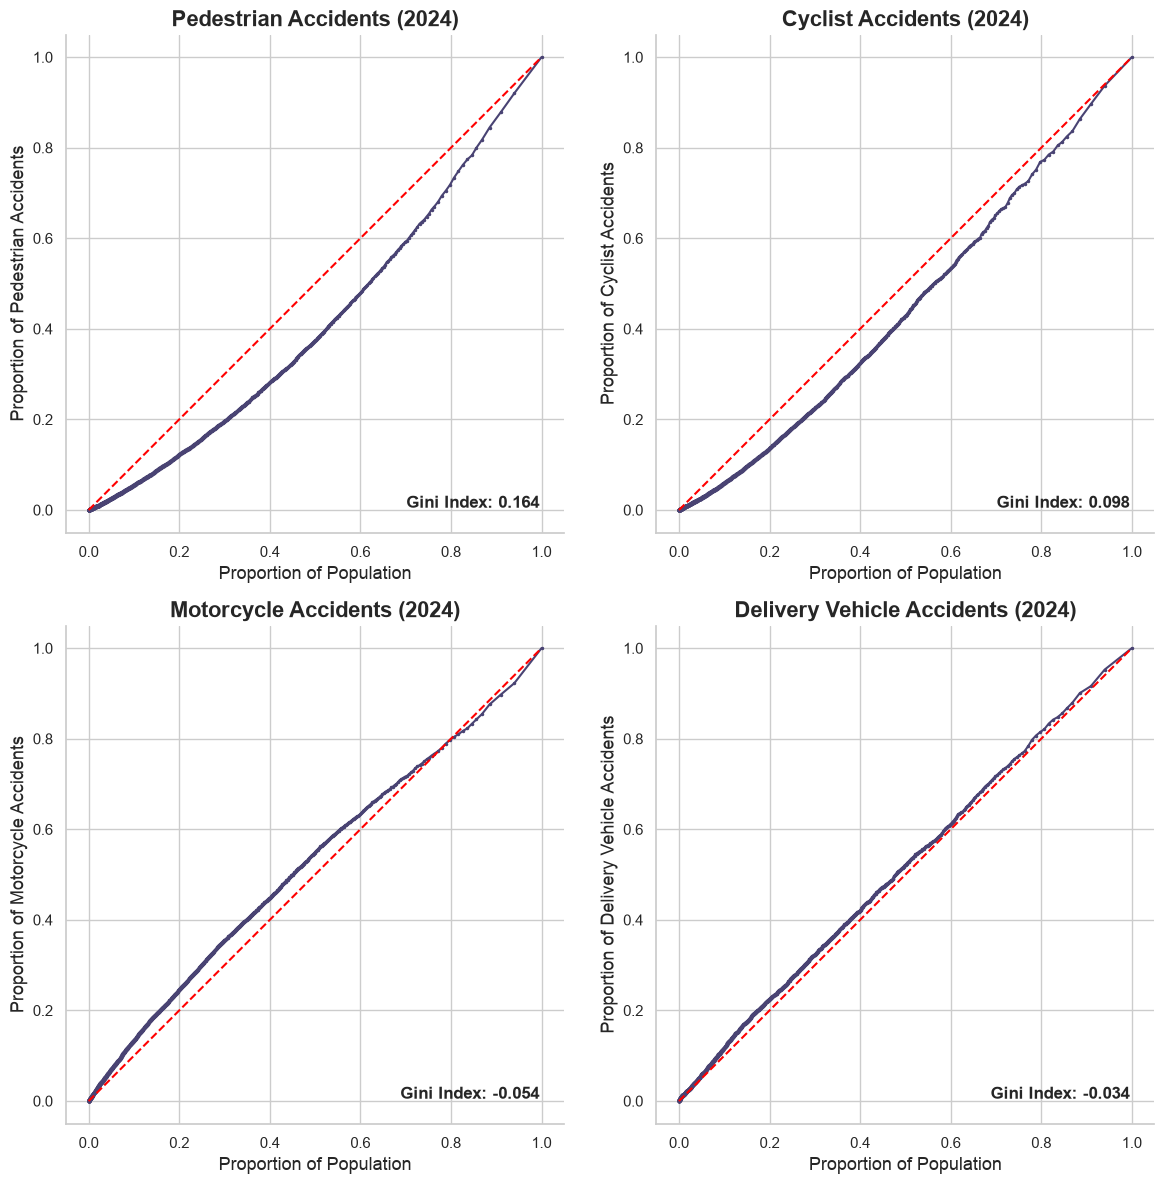

In [10]:
df_yr = df_merged[df_merged["UJAHR"] == 2024]

for name, group in [("gini_categories", list(vals.items())[:4]), ("gini_types", list(vals.items())[4:])]:
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    for ax, (col, label) in zip(axes.flat, group):
        plot_lorenz_curve(df_yr, 2024, val_label=col, val_title=label, ax=ax)
    fig.tight_layout()
    pl.save(fig, name)
    plt.show()

### Gini of Germany


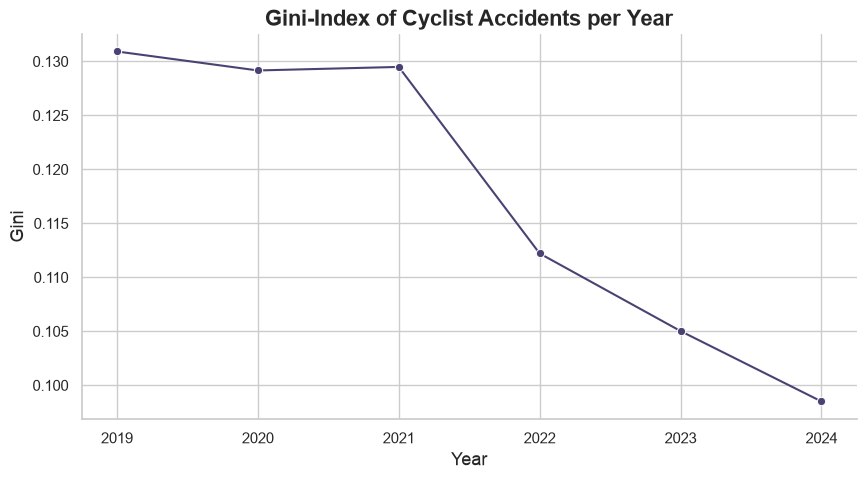

In [11]:
col = "IstRad"


def gini_by_year() -> pd.DataFrame:
    ginis = [
        calc_gini(df_merged[df_merged["UJAHR"] == year][["city", pop_label, col]], val_label=col)
        for year in YEARS
    ]
    return pd.DataFrame({"Year": YEARS, "Gini": ginis})


df_year = cached_df(f"gini/by_year_{col}_{YEARS[0]}-{YEARS[-1]}", gini_by_year)
ax = pl.line_chart(
    df_year, "Year", "Gini", f"Gini-Index of {vals[col]} per Year",
)
pl.save(ax.figure, f"gini_index_{col.lower()}_de")
plt.show()

### Gini per State


In [12]:
land_LUT: dict[int, str] = {
    1: "Schleswig-Holstein",
    2: "Hamburg",
    3: "Niedersachsen",
    4: "Bremen",
    5: "Nordrhein-Westfalen",  # data as from 2019
    6: "Hessen",
    7: "Rheinland-Pfalz",  # data as from 2017
    8: "Baden-Württemberg",
    9: "Bayern",
    10: "Saarland",  # data as from 2017
    11: "Berlin",  # data as from 2018
    12: "Brandenburg",  # data as from 2017
    13: "Mecklenburg-Vorpommern",  # data as from 2020
    14: "Sachsen",
    15: "Sachsen-Anhalt",
    16: "Thüringen",  # data as from 2019
}

In [13]:
def gini_by_state() -> pd.DataFrame:
    gini_arr: list[dict[str, float | str | int]] = []

    for year in YEARS:
        df_yr = df_merged[df_merged["UJAHR"] == year][[pop_label, col, "ULAND"]]

        for l_id, l_name in land_LUT.items():
            df_land = df_yr[df_yr["ULAND"] == f"{l_id:02}"]

            # Skip if we have no data for this land in this year e.g. NRW 2021
            if df_land.empty:
                continue

            gini = calc_gini(df_land, val_label=col)
            gini_arr.append(
                {
                    "Year": year,
                    "Land": l_name,
                    "Gini": gini,
                }
            )
    return pd.DataFrame(gini_arr)


df_gini = cached_df(f"gini/by_state_{col}_{YEARS[0]}-{YEARS[-1]}", gini_by_state)

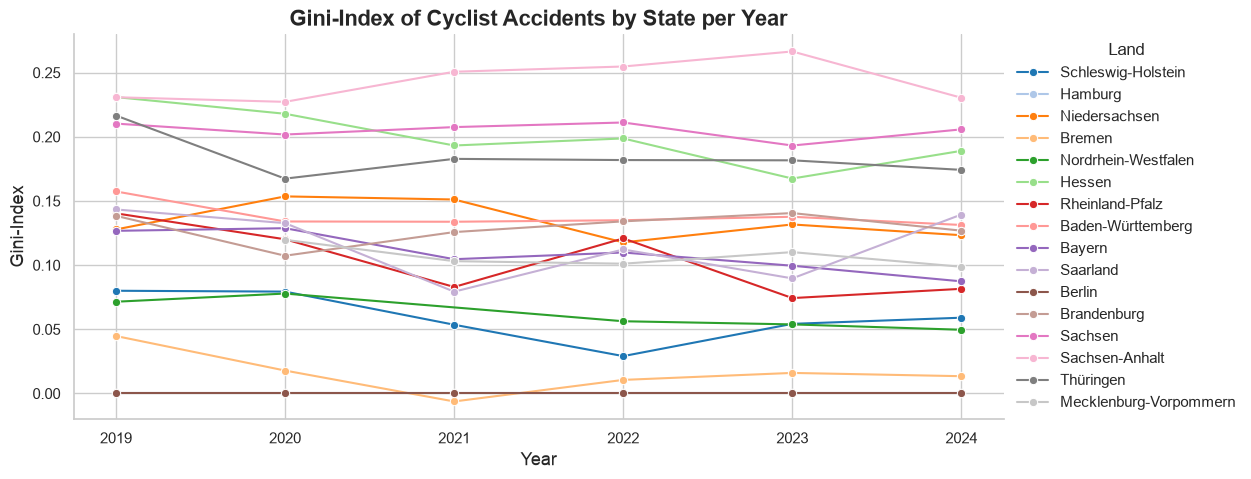

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
pl.line_chart(
    df_gini, "Year", "Gini", f"Gini-Index of {vals[col]} by State per Year",
    ylabel="Gini-Index", hue="Land", ax=ax,
)
pl.save(fig, f"gini_index_{col.lower()}_land")
plt.show()